In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings

# ── Rutas base ────────────────────────────────────────────────────
BASE    = '/content/drive/MyDrive/proyecto-auto-mpg/'
DATA    = BASE + 'data/'
NB      = BASE + 'Notebooks/'

# ── Cargar datos ───────────────────────────────────────
train_scaled = pd.read_csv(DATA + 'train_scaled.csv')
test_scaled  = pd.read_csv(DATA + 'test_scaled.csv')
train_raw    = pd.read_csv(DATA + 'train_raw.csv')
test_raw     = pd.read_csv(DATA + 'test_raw.csv')

with open(DATA + 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# ── Variables para el MLP ─────────────────────────────────────────
X_train = train_scaled.drop('mpg', axis=1)
y_train = train_scaled['mpg']
X_test  = test_scaled.drop('mpg', axis=1)
y_test  = test_scaled['mpg']

print(f'Train : {X_train.shape}')
print(f'Test  : {X_test.shape}')
print(f'Cols  : {list(X_train.columns)}')
print('\n Datos cargados correctamente')

Train : (318, 8)
Test  : (80, 8)
Cols  : ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_2', 'origin_3']

 Datos cargados correctamente


In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)

mlp = MLPRegressor(
    hidden_layer_sizes  = (64, 32, 16),
    activation          = 'relu',
    solver              = 'adam',
    max_iter            = 2000,
    random_state        = SEED,
    early_stopping      = True,
    validation_fraction = 0.1,
    n_iter_no_change    = 20,
)

mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=' * 40)
print('  MLP — Resultados en test')
print('=' * 40)
print(f'  MAE   : {mae:.4f} mpg')
print(f'  RMSE  : {rmse:.4f} mpg')
print(f'  R²    : {r2:.4f}')
print(f'  Épocas: {mlp.n_iter_}')
print('=' * 40)

  MLP — Resultados en test
  MAE   : 1.9427 mpg
  RMSE  : 2.4478 mpg
  R²    : 0.8886
  Épocas: 281


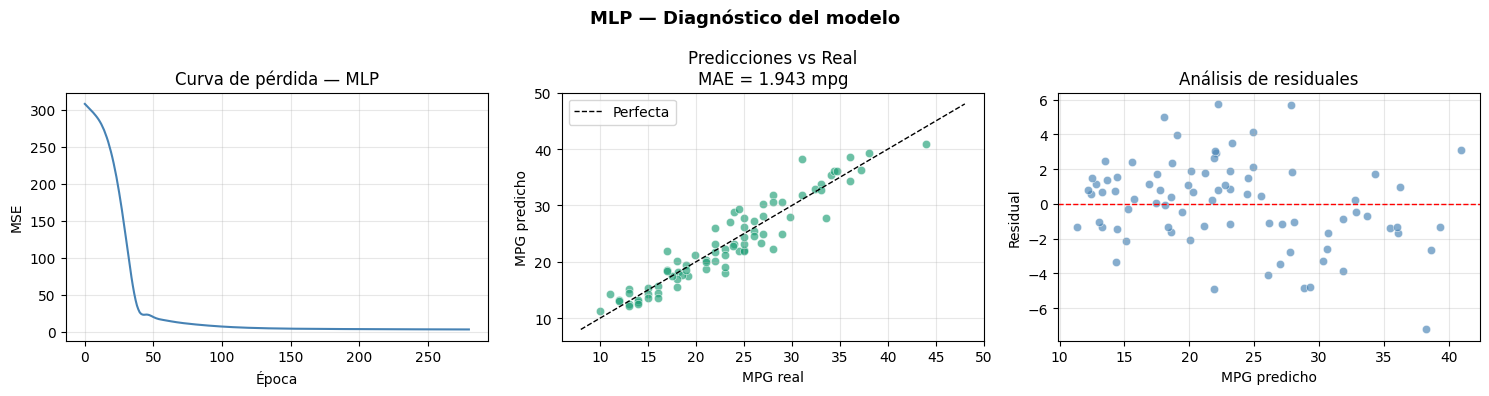

 Gráfica guardada en figures


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Gráfica 1: curva de pérdida ───────────────────────────────────
axes[0].plot(mlp.loss_curve_, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].set_title('Curva de pérdida — MLP')
axes[0].grid(True, alpha=0.3)

# ── Gráfica 2: predicciones vs real ──────────────────────────────
axes[1].scatter(y_test, y_pred, alpha=0.65, color='#1D9E75',
                edgecolors='white', linewidth=0.5)
axes[1].plot([8,48], [8,48], 'k--', linewidth=1, label='Perfecta')
axes[1].set_xlabel('MPG real')
axes[1].set_ylabel('MPG predicho')
axes[1].set_title(f'Predicciones vs Real\nMAE = {mae:.3f} mpg')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── Gráfica 3: residuales ─────────────────────────────────────────
residuales = y_test.values - y_pred
axes[2].scatter(y_pred, residuales, alpha=0.65, color='steelblue',
                edgecolors='white', linewidth=0.5)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('MPG predicho')
axes[2].set_ylabel('Residual')
axes[2].set_title('Análisis de residuales')
axes[2].grid(True, alpha=0.3)

plt.suptitle('MLP — Diagnóstico del modelo', fontsize=13, fontweight='bold')
plt.tight_layout()

# Guardar en la carpeta figures del equipo
plt.savefig('/content/drive/MyDrive/proyecto-auto-mpg/figures/MLP_diagnostico.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(' Gráfica guardada en figures')

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# CV necesita su propio scaler interno para no hacer data leakage
mlp_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        hidden_layer_sizes=(64,32,16), activation='relu',
        solver='adam', max_iter=2000, random_state=SEED,
        early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

# Dataset completo para CV (398 autos)
df_full = pd.concat([train_raw, test_raw], ignore_index=True)
X_full  = df_full.drop('mpg', axis=1)
y_full  = df_full['mpg']

cv = KFold(n_splits=10, shuffle=True, random_state=SEED)
cv_scores = -cross_val_score(
    mlp_cv, X_full, y_full,
    cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1
)

print('=== Validación Cruzada 10-Fold — MLP ===')
print(f'MAE por fold : {np.round(cv_scores, 3)}')
print(f'MAE medio    : {cv_scores.mean():.4f} mpg')
print(f'Desv. std    : {cv_scores.std():.4f} mpg')

=== Validación Cruzada 10-Fold — MLP ===
MAE por fold : [2.423 2.265 2.02  2.031 2.547 2.097 2.053 1.697 1.979 2.162]
MAE medio    : 2.1272 mpg
Desv. std    : 0.2275 mpg


  TABLA COMPARATIVA FINAL — AUTO MPG
  Split: random_state=42 | 80/20 | n=398
                  MAE    RMSE      R²
RF Optimizado  1.5547  2.1306  0.9156
RF Baseline    1.5964  2.1674  0.9126
AdaBoost       1.6529  2.2488  0.9059
XGBoost        1.7454  2.3237  0.8996
MLP            1.9427  2.4478  0.8886
OLS            2.2882  2.8877  0.8449
Ridge (L2)     2.2895  2.8914  0.8445
Lasso (L1)     2.2935  2.9085  0.8427
Elastic Net    2.2961  2.9037  0.8432


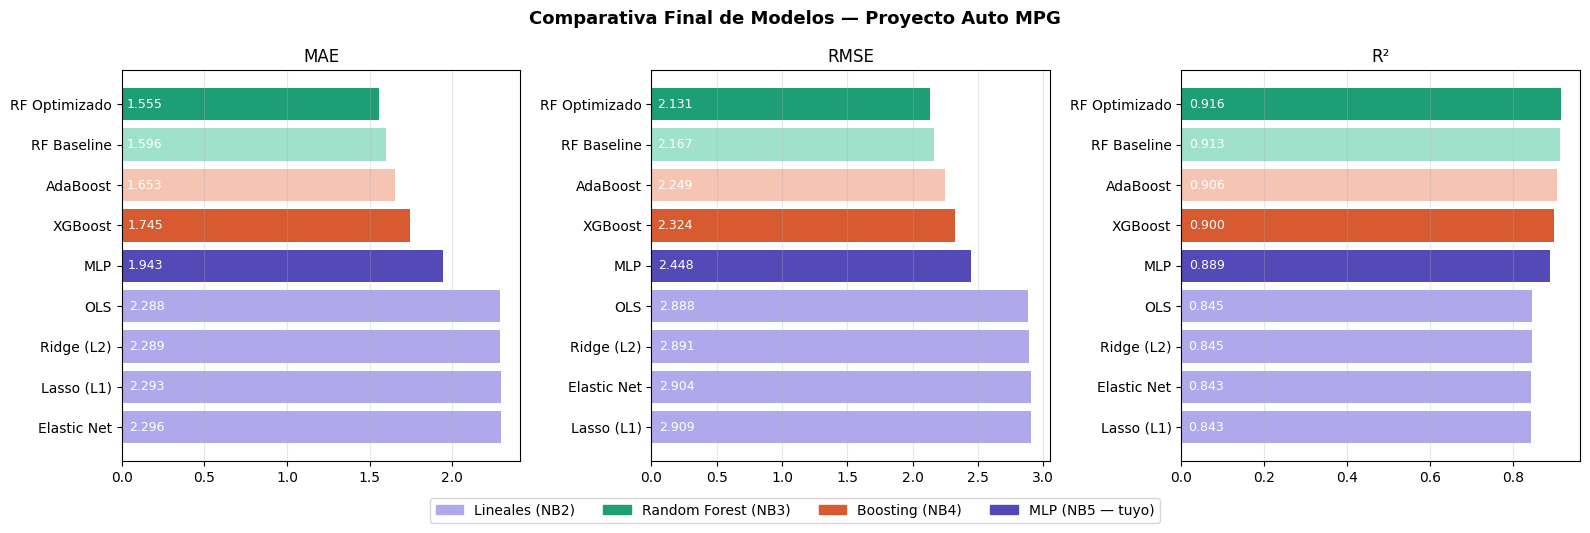

Gráfica guardada en figures/


In [ ]:
# ── Tabla comparativa final del equipo ────────────────────────────
resultados = {
    'OLS'           : {'MAE': 2.2882, 'RMSE': 2.8877, 'R²': 0.8449},
    'Ridge (L2)'    : {'MAE': 2.2895, 'RMSE': 2.8914, 'R²': 0.8445},
    'Lasso (L1)'    : {'MAE': 2.2935, 'RMSE': 2.9085, 'R²': 0.8427},
    'Elastic Net'   : {'MAE': 2.2961, 'RMSE': 2.9037, 'R²': 0.8432},
    'RF Baseline'   : {'MAE': 1.5964, 'RMSE': 2.1674, 'R²': 0.9126},
    'RF Optimizado' : {'MAE': 1.5547, 'RMSE': 2.1306, 'R²': 0.9156},
    'AdaBoost'      : {'MAE': 1.6529, 'RMSE': 2.2488, 'R²': 0.9059},
    'XGBoost'       : {'MAE': 1.7454, 'RMSE': 2.3237, 'R²': 0.8996},
    'MLP'           : {'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R²': round(r2,4)},
}

tabla = pd.DataFrame(resultados).T.sort_values('MAE')

print('=' * 52)
print('  TABLA COMPARATIVA FINAL — AUTO MPG')
print('  Split: random_state=42 | 80/20 | n=398')
print('=' * 52)
print(tabla.to_string())
print('=' * 52)

# ── Gráfica de barras ─────────────────────────────────────────────
colores = {
    'OLS':'#AFA9EC', 'Ridge (L2)':'#AFA9EC',
    'Lasso (L1)':'#AFA9EC', 'Elastic Net':'#AFA9EC',
    'RF Baseline':'#9FE1CB', 'RF Optimizado':'#1D9E75',
    'AdaBoost':'#F5C4B3', 'XGBoost':'#D85A30',
    'MLP':'#534AB7'
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metrica in zip(axes, ['MAE', 'RMSE', 'R²']):
    asc   = (metrica != 'R²')
    datos = tabla[metrica].sort_values(ascending=asc)
    bars  = ax.barh(datos.index, datos.values,
                    color=[colores.get(m, '#B4B2A9') for m in datos.index])
    ax.set_title(metrica, fontsize=12)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    # Etiqueta con el valor dentro de cada barra
    for bar, val in zip(bars, datos.values):
        ax.text(val * 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9,
                color='white', fontweight='500')

from matplotlib.patches import Patch
leyenda = [
    Patch(color='#AFA9EC', label='Lineales (NB2)'),
    Patch(color='#1D9E75', label='Random Forest (NB3)'),
    Patch(color='#D85A30', label='Boosting (NB4)'),
    Patch(color='#534AB7', label='MLP (NB5 — tuyo)'),
]
fig.legend(handles=leyenda, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.06), fontsize=10)

plt.suptitle('Comparativa Final de Modelos — Proyecto Auto MPG',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/proyecto-auto-mpg/figures/comparativa_final.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada en figures/')

In [ ]:
# ── Resumen final para el informe ─────────────────────────────────
print('RESUMEN NOTEBOOK 5 — MLP + COMPARATIVA FINAL')
print('=' * 50)
print(f'Modelo         : MLP (Perceptrón Multicapa)')
print(f'Arquitectura   : 8 → 64 → 32 → 16 → 1')
print(f'Activación     : ReLU (capas ocultas) / Lineal (salida)')
print(f'Optimizador    : Adam')
print(f'Early stopping : Sí  (paró en época {mlp.n_iter_} de 2000)')
print(f'Datos          : train_scaled.csv / test_scaled.csv del equipo')
print(f'Split          : random_state=42 | 80/20')
print('─' * 50)
print(f'MAE  (test)    : {mae:.4f} mpg')
print(f'RMSE (test)    : {rmse:.4f} mpg')
print(f'R²   (test)    : {r2:.4f}')
print('─' * 50)
print(f'MAE  (CV-10)   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f} mpg')
print('─' * 50)
print(f'Posición final : 5° de 9 modelos (por MAE)')
print(f'Mejor modelo   : RF Optimizado  MAE=1.5547')
print('=' * 50)

RESUMEN NOTEBOOK 5 — MLP + COMPARATIVA FINAL
Modelo         : MLP (Perceptrón Multicapa)
Arquitectura   : 8 → 64 → 32 → 16 → 1
Activación     : ReLU (capas ocultas) / Lineal (salida)
Optimizador    : Adam
Early stopping : Sí  (paró en época 281 de 2000)
Datos          : train_scaled.csv / test_scaled.csv del equipo
Split          : random_state=42 | 80/20
──────────────────────────────────────────────────
MAE  (test)    : 1.9427 mpg
RMSE (test)    : 2.4478 mpg
R²   (test)    : 0.8886
──────────────────────────────────────────────────
MAE  (CV-10)   : 2.1272 ± 0.2275 mpg
──────────────────────────────────────────────────
Posición final : 5° de 9 modelos (por MAE)
Mejor modelo   : RF Optimizado  MAE=1.5547


In [ ]:
import shutil

# Guardar el notebook en la carpeta Notebooks del equipo
ruta_destino = '/content/drive/MyDrive/proyecto-auto-mpg/Notebooks/05_MLP_Comparativa_Final.ipynb'

# Obtener el nombre del notebook actual
ruta_actual = '/content/' + '05_MLP_Comparativa_Final.ipynb'

# En Colab el notebook está aquí:
import os, json, requests

# Copiamos directamente usando la API de Colab
from google.colab import _message
nb_name = _message.blocking_request('get_ipynb', request='', timeout_sec=60)

with open(ruta_destino, 'w') as f:
    json.dump(nb_name['ipynb'], f)

print(f' Notebook guardado en:')
print(f'   {ruta_destino}')
print()
print('Verificando...')
!ls -lh "/content/drive/MyDrive/proyecto-auto-mpg/Notebooks/"

 Notebook guardado en:
   /content/drive/MyDrive/proyecto-auto-mpg/Notebooks/05_MLP_Comparativa_Final.ipynb

Verificando...
total 1.9M
-rw------- 1 root root 192K Jun 23 04:57  05_MLP_Comparativa_Final.ipynb
-rw------- 1 root root 456K Jun 23 02:27  Análisis_Lineal_MPG.ipynb
-rw------- 1 root root 487K Jun 23 04:18  EDA_preprocesamiento.ipynb
-rw------- 1 root root 190K Jun 23 04:57  MLP_Comparativa.ipynb
-rw------- 1 root root 223K Jun 23 02:27  RandomForest.ipynb
-rw------- 1 root root 358K Jun 23 02:27 'XGBoost&AdaBoost.ipynb'
